# TM10007 Assignment template

In [2]:
# Run this to use from colab environment
!pip install -q --upgrade git+https://github.com/jveenland/tm10007_ml.git

## Importing packages 


In [56]:
# General packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets as ds
import seaborn as sns

# Classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm

# statistics
from scipy.stats import shapiro
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, auc 



## Data loading and cleaning

Below are functions to load the dataset of your choice. After that, it is all up to you to create and evaluate a classification method. Beware, there may be missing values in these datasets. Good luck!

In [57]:
from worcliver.load_data import load_data

# Load the data
data = load_data()

# Replace the labels with binary labels
data_binary = data.copy()
data_binary["label"] = data_binary["label"].map({"malignant": 1, "benign": 0})

# Print number of samples and columns
print(f"The number of samples: {len(data_binary.index)}")
print(f"The number of columns: {len(data_binary.columns)}")
print(f"The number of malignant samples: {sum(data_binary['label']==1)}")
print(f"The number of benign samples: {sum(data_binary['label']==0)}")

The number of samples: 186
The number of columns: 494
The number of malignant samples: 94
The number of benign samples: 92


## Data splitting

In [58]:
# Split the dataset in features and labels
X = data_binary.drop(columns=["label"])
y = data_binary["label"]

# Split the dataset in train and test part
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print the number of samples in the train and test set
print(f"The number of samples in the train set: {len(X_train.index)}")
print(f"The number of samples in the test set: {len(X_test.index)}")

The number of samples in the train set: 148
The number of samples in the test set: 38


## Pre-Processing


In [59]:
# Checking for duplicate samples
duplicate_samples = data_binary[data_binary.duplicated()]
if len(duplicate_samples) > 0:
    print(f"Number of duplicate rows: {len(duplicate_samples)}")
else:
    print("No duplicate sample found.")   
# Remove duplicate samples
data_binary = data_binary.drop_duplicates()

# Checking for duplicate features
duplicate_features = data_binary.columns[data_binary.columns.duplicated()]
if len(duplicate_features) > 0:
    print(f"Number of duplicate features: {len(duplicate_features)}")
    print("Duplicate feature names:")
    print(list(duplicate_features))
    # Remove duplicate features
    data_binary = data_binary.loc[:, ~data_binary.columns.duplicated()]   
else:
    print("No duplicate features found.")

# Checking for constant features
constant_features = data_binary.columns[data_binary.nunique() == 1]
print(f"Number of constant features: {len(constant_features)}")
if len(constant_features) > 0:
    print(f"Constant features names: {list(constant_features)}")
    data_binary.drop(columns=constant_features, inplace=True)

# Checking for missing data
# Check for missing values
print(f"Amount of missing data: {data_binary.isna().sum().sum()}")
# Check for infinite values
print(f"Amount of infinite data: {data_binary.map(np.isinf).sum().sum()}")


No duplicate sample found.
No duplicate features found.
Number of constant features: 17
Constant features names: ['PREDICT_original_tf_LBP_min_R3_P12', 'PREDICT_original_tf_LBP_max_R3_P12', 'PREDICT_original_tf_LBP_peak_R3_P12', 'PREDICT_original_tf_LBP_peak_position_R3_P12', 'PREDICT_original_tf_LBP_range_R3_P12', 'PREDICT_original_tf_LBP_max_R8_P24', 'PREDICT_original_tf_LBP_peak_R8_P24', 'PREDICT_original_tf_LBP_peak_position_R8_P24', 'PREDICT_original_tf_LBP_max_R15_P36', 'PREDICT_original_tf_LBP_peak_R15_P36', 'PREDICT_original_tf_LBP_peak_position_R15_P36', 'PREDICT_original_phasef_phasecong_min_WL3_N5', 'PREDICT_original_phasef_phasecong_peak_WL3_N5', 'PREDICT_original_phasef_phasecong_peak_position_WL3_N5', 'PREDICT_original_phasef_phasesym_min_WL3_N5', 'PREDICT_original_phasef_phasesym_peak_WL3_N5', 'PREDICT_original_phasef_phasesym_peak_position_WL3_N5']
Amount of missing data: 0
Amount of infinite data: 0


## Scaling 
##### First check the distribution of the data, we check for normal and not normal distribution and we check the data on outliers

In [60]:
k = 1.5  # IQR factor

# Calculating prescence and number of outliers
columns_many_outliers_count = 0

for column in X_train:
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1
    cut_off = IQR * k
    lower, upper = Q1 - cut_off, Q3 + cut_off

    outliers = X_train[(X_train[column] < (Q1 - 1.5 * IQR)) | (X_train[column] > (Q3 + 1.5 * IQR))]
    outliers_count = outliers.shape[0]

    if outliers_count > cut_off * X_train.shape[0]:
        columns_many_outliers_count += 1

perc_columns_many_outliers = (columns_many_outliers_count / len(X_train.columns))*100
print(f"Number of columns with many outliers: {columns_many_outliers_count}/{len(X_train.columns)} = {perc_columns_many_outliers:.2f}%")


Number of columns with many outliers: 117/493 = 23.73%


## Classifiers


==> Trainen en tunen van: LogisticRegression


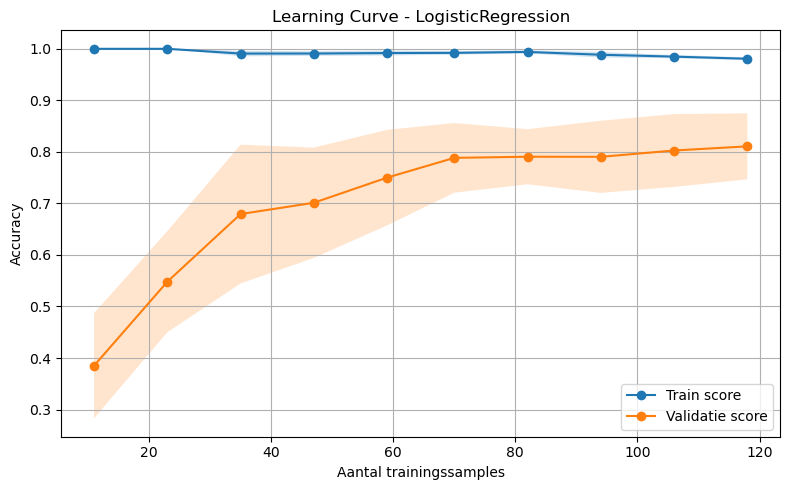


==> Trainen en tunen van: SVM


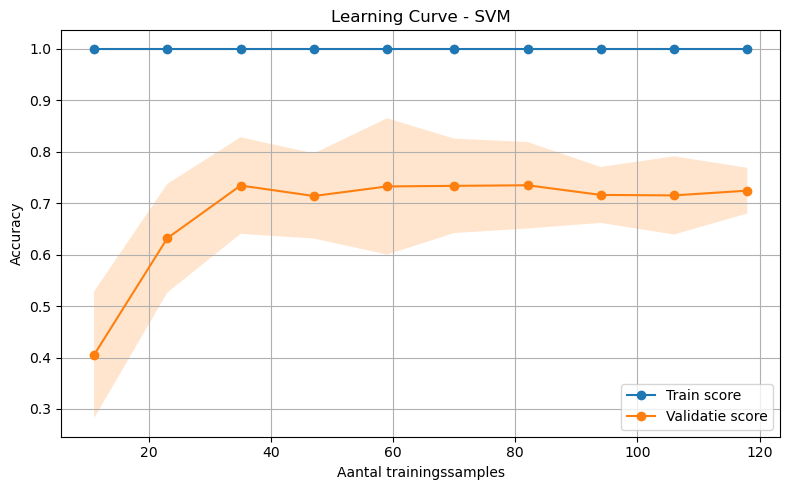


==> Trainen en tunen van: RandomForest


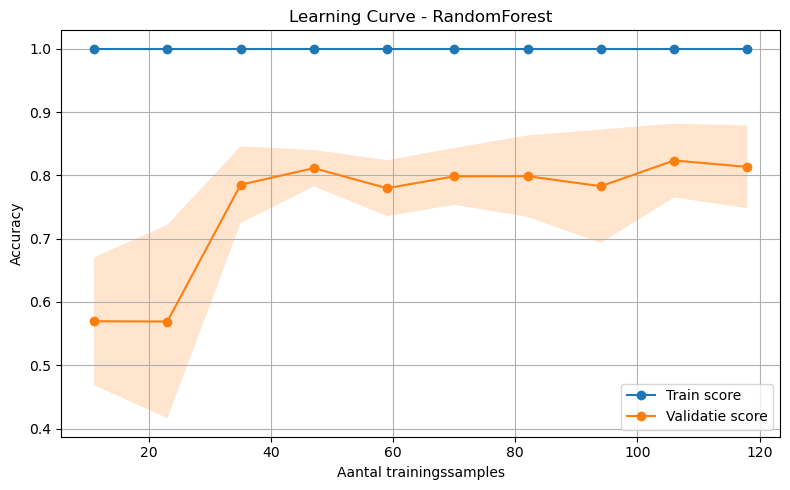


==> Trainen en tunen van: KNN


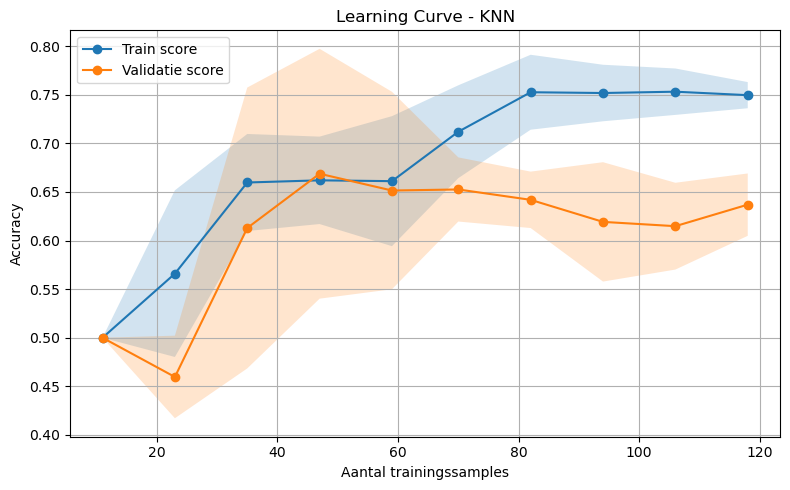


Resultaten per model:

 LogisticRegression
  Beste CV-score:     0.771
  Accuracy op testset: 0.763
  AUC op testset:      0.792
   Classificatie rapport:
              precision    recall  f1-score   support

           0       0.78      0.74      0.76        19
           1       0.75      0.79      0.77        19

    accuracy                           0.76        38
   macro avg       0.76      0.76      0.76        38
weighted avg       0.76      0.76      0.76        38


 SVM
  Beste CV-score:     0.682
  Accuracy op testset: 0.763
  AUC op testset:      0.526
   Classificatie rapport:
              precision    recall  f1-score   support

           0       0.81      0.68      0.74        19
           1       0.73      0.84      0.78        19

    accuracy                           0.76        38
   macro avg       0.77      0.76      0.76        38
weighted avg       0.77      0.76      0.76        38


 RandomForest
  Beste CV-score:     0.783
  Accuracy op testset: 0.553


In [61]:
# Modellen + bijbehorende hyperparametergrids
models = {
    "LogisticRegression": {
        "model": LogisticRegression(max_iter=10000),
        "params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l2"],
            "model__solver": ["lbfgs"]
        }
    },
    "SVM": {
        "model": SVC(probability=True),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["linear", "rbf"],
            "model__gamma": ["scale", "auto"]
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 10],
            "model__max_features": ["sqrt", "log2"]
        }
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "model__n_neighbors": [3, 5, 7, 11],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2]  # p=1: manhattan, p=2: euclidean afstand
        }
    }
}

# Resultaten opslaan
results = {}

# Loop door modellen
for name, config in models.items():
    print(f"\n==> Trainen en tunen van: {name}")
    
    # Pipeline: standaardiseren + model (voor modellen die dat nodig hebben)
    pipe = Pipeline([
        ('scaler', RobustScaler()),
        ('model', config['model'])
    ])
    
    # Grid search
    grid = GridSearchCV(pipe, config['params'], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)

    # Beste model voorspelt op testset
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    # Score berekenen
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=False)

    # Probeer ook AUC (alleen bij binaire classificatie en predict_proba)
    try:
        y_proba = best_model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    except:
        auc = None
    
    # Learning curve berekenen
    train_sizes, train_scores, val_scores = learning_curve(
        best_model,
        X_train,
        y_train,
        cv=5,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='roc_auc',
        n_jobs=-1
    )
    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    # Plotten
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, 'o-', label='Train score')
    plt.plot(train_sizes, val_mean, 'o-', label='Validatie score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)
    plt.title(f"Learning Curve - {name}")
    plt.xlabel("Aantal trainingssamples")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Resultaten opslaan
    results[name] = {
        "best_score_cv": grid.best_score_,
        "best_params": grid.best_params_,
        "accuracy_test": acc,
        "report": report,
        "auc": auc,
        "model_object": best_model
    }

print("\nResultaten per model:")
for name, res in results.items():
    print(f"\n {name}")
    print(f"  Beste CV-score:     {res['best_score_cv']:.3f}")
    print(f"  Accuracy op testset: {res['accuracy_test']:.3f}")
    if res['auc'] is not None:
        print(f"  AUC op testset:      {res['auc']:.3f}")
    print("   Classificatie rapport:")
    print(res['report'])



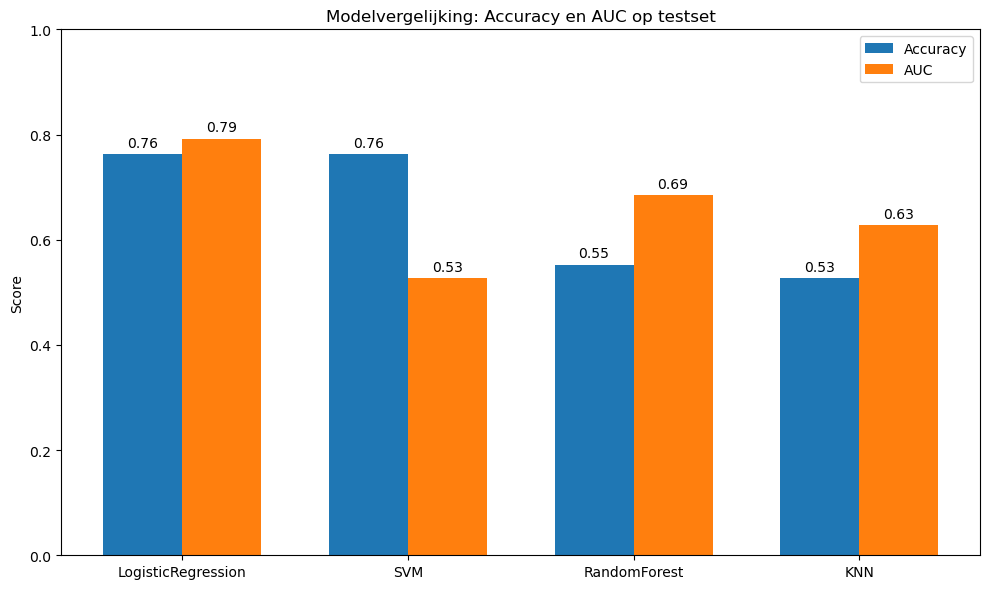

In [62]:
# Verzamel scores voor plot
model_names = []
accuracies = []
aucs = []

for name, res in results.items():
    model_names.append(name)
    accuracies.append(res['accuracy_test'])
    aucs.append(res['auc'] if res['auc'] is not None else 0)

# Plot maken
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy')
rects2 = ax.bar(x + width/2, aucs, width, label='AUC')

# Labels en styling
ax.set_ylabel('Score')
ax.set_title('Modelvergelijking: Accuracy en AUC op testset')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim(0, 1)

# Scores boven de balken tonen
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f"{height:.2f}", xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')

add_labels(rects1)
add_labels(rects2)

plt.tight_layout()
plt.show()


[LogisticRegression] AUC = 0.7922437673130194, model = <class 'sklearn.pipeline.Pipeline'>
[SVM] AUC = 0.5263157894736842, model = <class 'sklearn.pipeline.Pipeline'>
[RandomForest] AUC = 0.6855955678670359, model = <class 'sklearn.pipeline.Pipeline'>
[KNN] AUC = 0.6274238227146814, model = <class 'sklearn.pipeline.Pipeline'>


C:\Users\anouk\AppData\Local\Temp\ipykernel_9100\1177931679.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


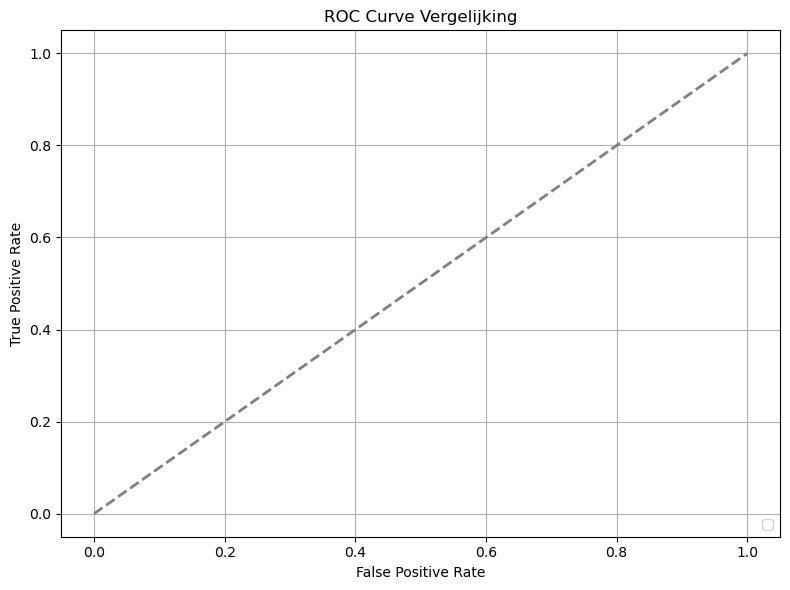

In [63]:
# === Gezamenlijke ROC-curve ===
plt.figure(figsize=(8, 6))
lw = 2
plt.plot([0, 1], [0, 1], linestyle='--', lw=lw, color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Vergelijking')

for name, res in results.items():
    model = res['model_object']
    auc_val = res['auc']
    print(f"[{name}] AUC = {auc_val}, model = {type(model)}")
    if auc_val is not None:
        try:
            y_proba = model.predict_proba(X_test)
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=lw, label=f'{name} (AUC = {roc_auc:.2f})')
        except:
            continue

plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()